### making GPU go Brrrrr

In [4]:
import torch, os, math
import torchvision as tv
import torchvision.transforms.functional as tvf
from torchvision import io
import matplotlib.pyplot as plt
from torch.utils.cpp_extension import load_inline

In [17]:
img = io.read_image("artifacts/puppy.png")
print(img.shape)
img[:2,:3,:4]

torch.Size([3, 266, 474])


tensor([[[174, 174, 174, 173],
         [174, 174, 174, 173],
         [175, 175, 175, 174]],

        [[127, 127, 127, 126],
         [127, 127, 127, 126],
         [128, 128, 128, 127]]], dtype=torch.uint8)

In [18]:
def show_img(x, figsize=(4,3), **kwargs):
    plt.figure(figsize=figsize)
    plt.axis("off")
    if len(x.shape) == 3: x = x.permute(1, 2, 0) # CHW = HWC
    plt.imshow(x.cpu(), **kwargs)

In [19]:
img2 = tvf.resize(img, 150, antialias=True)
ch, h, w = img2.shape
ch, h, w, h*w

(3, 150, 267, 40050)

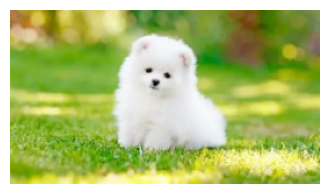

In [20]:
show_img(img2)

### basics

In [21]:
def rgb2grey_py(x):
    c,h,w = x.shape
    n = h * w
    x = x.flatten()
    res = torch.empty(n, dtype=x.dtype, device=x.device)
    for i in range(n): res[i] = 0.2989*x[i] + 0.5870*x[i+n] + 0.1140*x[i+2*n]
    return res.view(h, w)

In [22]:
%%time
img_g = rgb2grey_py(img2)

CPU times: total: 1.53 s
Wall time: 1.6 s


In [23]:
img2.flatten()

tensor([174, 174, 171,  ...,  83,  90,  99], dtype=torch.uint8)

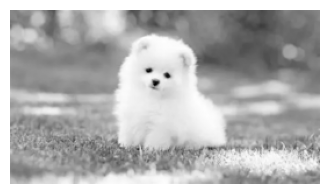

In [24]:
show_img(img_g, cmap='gray')

### Python Kernels

In [31]:
def run_kernel(f, times, *args):
    for i in range(times): f(i, *args)

In [32]:
def rgb2grey_k(i, x, out, n):
    out[i] = 0.2989*x[i] + 0.5870*x[i+n] + 0.1140*x[i+2*n]

In [33]:
def rgb2grey_pyk(x):
    c, h, w = x.shape
    n = h * w
    x = x.flatten()
    res = torch.empty(n, dtype=x.dtype, device=x.device)
    run_kernel(rgb2grey_k, h*w, x, res, n)
    return res.view(h, w)

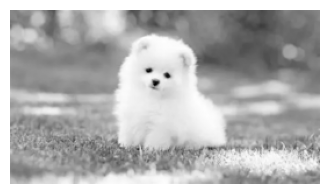

In [34]:
img_g = rgb2grey_pyk(img2)
show_img(img_g, cmap='gray')